# 01 · Rede neural do zero, só com NumPy

Antes de usar Keras ou PyTorch, este notebook abre a caixa-preta: cada peça de uma rede
neural — soma ponderada, ativação, perda, gradiente e atualização dos pesos — é escrita à
mão e aplicada à base **Coração de Dados** (68.551 pacientes, base curada do projeto de
agrupamento).

Diferente do projeto anterior, aqui o problema é **supervisionado**: a rede aprende a
prever `cardio` (presença de doença cardiovascular).

Roteiro, na mesma progressão dos exercícios da disciplina:

1. Um neurônio linear aprende a **soma** de dois números.
2. Um neurônio **sigmoide** (regressão logística) classifica pacientes com 2 variáveis.
3. Uma **rede multicamada** com backpropagation, inicialização He, mini-lotes, L2 e parada antecipada.
4. **Verificação do gradiente**: a derivada escrita à mão bate com a derivada numérica?
5. O efeito da **taxa de aprendizado**.

In [1]:
import sys
from pathlib import Path

# Permite importar `src` mesmo fora do ambiente do uv (ex.: Colab com o repositório clonado).
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.dados import preparar
from src.model import avaliacao
from src.model.mlp_numpy import MLPNumpy, entropia_cruzada_binaria, sigmoide
from src.utils import graficos
from src.utils.io import configurar_estilo, salvar_figura, salvar_tabela

configurar_estilo()
SECAO = "01-mlp-numpy"

## 1. Um neurônio aprende a soma

O menor exemplo possível: um neurônio com dois pesos e um viés, sem ativação. A cada
exemplo, calcula a previsão, mede o erro e ajusta cada peso na direção que reduz o erro —
é o **gradiente descendente**. Se tudo der certo, os pesos convergem para 1 e o viés para 0,
porque `resultado = 1·a + 1·b + 0`.

In [2]:
dados_soma = [(0, 0, 0), (1, 0, 1), (0, 1, 1), (1, 1, 2), (2, 3, 5), (4, 2, 6), (-1, 2, 1)]

peso1 = peso2 = vies = 0.0
taxa = 0.01

for epoca in range(2000):
    for a, b, correto in dados_soma:
        previsao = a * peso1 + b * peso2 + vies
        erro = previsao - correto
        # derivada do erro quadrático ½·erro² em relação a cada parâmetro
        peso1 -= taxa * erro * a
        peso2 -= taxa * erro * b
        vies -= taxa * erro

print(f"peso1 = {peso1:.4f}   peso2 = {peso2:.4f}   viés = {vies:.4f}")
print(f"A rede calcula 7 + 5 = {7 * peso1 + 5 * peso2 + vies:.3f}")

peso1 = 1.0000   peso2 = 1.0000   viés = 0.0000
A rede calcula 7 + 5 = 12.000


## 2. Um neurônio sigmoide classifica pacientes

Agora a saída passa por uma **sigmoide**, que espreme qualquer número no intervalo
(0, 1) — pode ser lida como probabilidade. Com a perda de **entropia cruzada binária**, o
gradiente em relação à soma ponderada fica simplesmente `p − y`.

Usamos só duas variáveis clínicas, já padronizadas: **pressão sistólica** e **idade**.
Com duas entradas dá para desenhar a fronteira de decisão, que para um único neurônio é
sempre uma reta.

In [3]:
particao = preparar()
nomes = particao.nomes
i_pa, i_idade = nomes.index("ap_hi"), nomes.index("idade_anos")

X2 = particao.X_treino[:, [i_pa, i_idade]]
X2_val = particao.X_val[:, [i_pa, i_idade]]
y, y_val = particao.y_treino, particao.y_val

print(f"Treino: {X2.shape}   Validação: {X2_val.shape}")
print(f"Prevalência de doença no treino: {y.mean():.1%}")

Treino: (41130, 2)   Validação: (13710, 2)
Prevalência de doença no treino: 49.5%


In [4]:
rng = np.random.default_rng(config.SEMENTE)
w = rng.normal(0, 0.01, size=2)
b = 0.0
taxa = 0.1
historico_neuronio = []

for epoca in range(200):
    p = sigmoide(X2 @ w + b)
    grad_z = p - y  # derivada da entropia cruzada + sigmoide
    w -= taxa * X2.T @ grad_z / len(y)
    b -= taxa * grad_z.mean()
    historico_neuronio.append(entropia_cruzada_binaria(y, p))

p_val = sigmoide(X2_val @ w + b)
print(f"Pesos: pressão = {w[0]:.3f}, idade = {w[1]:.3f}, viés = {b:.3f}")
print(f"AUC na validação com 2 variáveis: {avaliacao.metricas(y_val, p_val)['auc_roc']:.3f}")

Pesos: pressão = 1.007, idade = 0.388, viés = 0.009
AUC na validação com 2 variáveis: 0.779


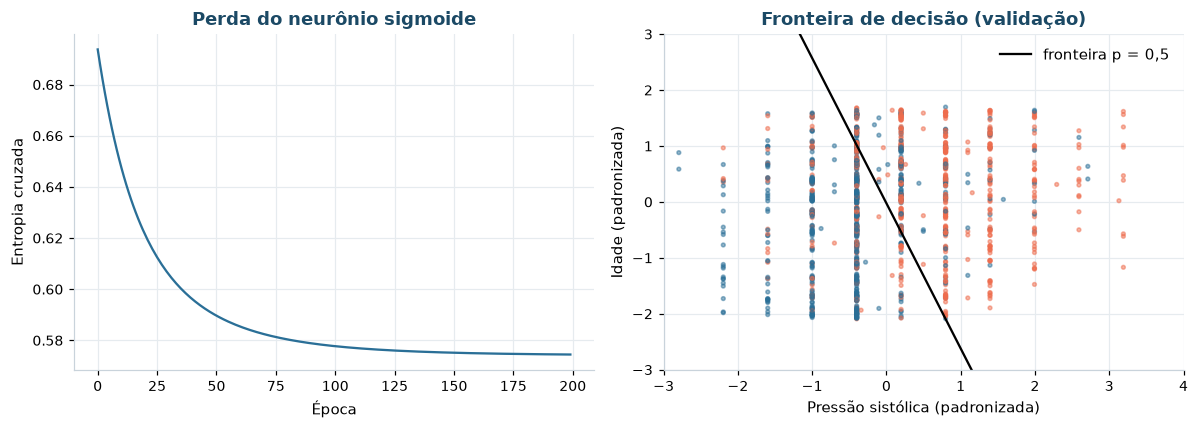

In [5]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(historico_neuronio, color=config.AZUL_COBALTO)
eixos[0].set(title="Perda do neurônio sigmoide", xlabel="Época", ylabel="Entropia cruzada")

amostra = rng.choice(len(X2_val), 1500, replace=False)
cores = np.where(y_val[amostra] == 1, config.CORAL, config.AZUL_COBALTO)
eixos[1].scatter(X2_val[amostra, 0], X2_val[amostra, 1], c=cores, s=6, alpha=0.5)
xs = np.linspace(-3, 4, 50)
eixos[1].plot(xs, -(w[0] * xs + b) / w[1], color="black", linewidth=1.5, label="fronteira p = 0,5")
eixos[1].set(
    title="Fronteira de decisão (validação)",
    xlabel="Pressão sistólica (padronizada)",
    ylabel="Idade (padronizada)",
    xlim=(-3, 4),
    ylim=(-3, 3),
)
eixos[1].legend()
fig.tight_layout()
salvar_figura(fig, SECAO, "neuronio-sigmoide", pd.DataFrame({"perda": historico_neuronio}))
plt.show()

A fronteira inclinada mostra que o neurônio combina as duas variáveis: um paciente mais
velho precisa de menos pressão para ser classificado como doente. Mas uma reta é tudo o
que um neurônio sozinho consegue. Para curvas, precisamos de **camadas ocultas**.

## 3. Rede multicamada com backpropagation

A classe `MLPNumpy` (em `src/model/mlp_numpy.py`) implementa:

| Peça | Implementação |
|:--|:--|
| Camadas ocultas | Dense + ReLU |
| Saída | Dense + sigmoide → P(cardio = 1) |
| Perda | Entropia cruzada binária + penalidade L2 |
| Inicialização | He: `N(0, √(2/n_entrada))`, adequada à ReLU |
| Otimização | Gradiente descendente em mini-lotes embaralhados |
| Regularização | L2 e parada antecipada pela perda de validação |

Agora com **todas as 16 entradas** (6 contínuas padronizadas, 6 colunas one-hot de
colesterol e glicose e 4 binárias).

In [6]:
mlp = MLPNumpy(n_entradas=particao.n_entradas, ocultas=(32, 16), taxa=0.05, l2=1e-4)
print(f"Parâmetros treináveis: {mlp.n_parametros}")

mlp.fit(
    particao.X_treino, particao.y_treino, particao.X_val, particao.y_val,
    epocas=150, lote=256, paciencia=10, verbose=True,
)
print(f"Épocas executadas: {len(mlp.historico['perda'])}")

Parâmetros treináveis: 1089
época   0  perda 0.5661  perda_val 0.5647


época  10  perda 0.5472  perda_val 0.5460


época  20  perda 0.5445  perda_val 0.5435
época  30  perda 0.5429  perda_val 0.5426


época  40  perda 0.5421  perda_val 0.5424
época  50  perda 0.5411  perda_val 0.5420


época  60  perda 0.5404  perda_val 0.5420
época  70  perda 0.5401  perda_val 0.5419


Épocas executadas: 75


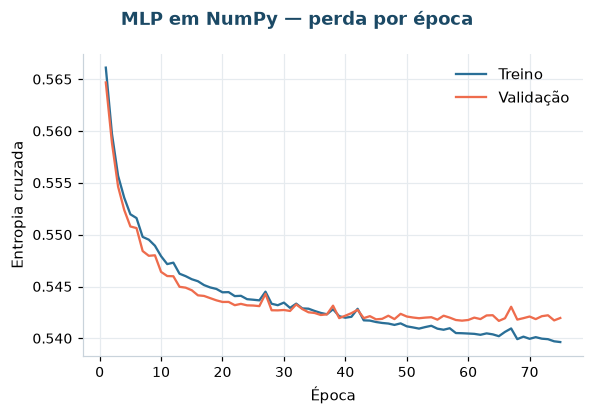

,auc_roc,auc_pr,acuracia,sensibilidade,especificidade,precisao,f1,brier,limiar
MLP NumPy (16 entradas),0.8009,0.7806,0.7323,0.6962,0.7677,0.7459,0.7201,0.1807,0.5
Neurônio sigmoide (2 variáveis),0.7787,0.7615,0.7162,0.6515,0.7796,0.7432,0.6943,0.1931,0.5


In [7]:
fig, dados = graficos.curvas_de_treino(mlp.historico, "MLP em NumPy — perda por época")
salvar_figura(fig, SECAO, "curvas-mlp-numpy", dados)
plt.show()

p_val_mlp = mlp.predict_proba(particao.X_val)
resultados = {
    "Neurônio sigmoide (2 variáveis)": avaliacao.metricas(y_val, p_val),
    "MLP NumPy (16 entradas)": avaliacao.metricas(y_val, p_val_mlp),
}
tabela = avaliacao.tabela_comparativa(resultados)
salvar_tabela(tabela, SECAO, "neuronio-vs-mlp-validacao")
tabela

## 4. Verificação do gradiente

Um erro de sinal no backpropagation não quebra o código — a rede só aprende pior, em
silêncio. A forma clássica de conferir é comparar o gradiente analítico com a
**diferença finita central**:

$$\frac{\partial L}{\partial w} \approx \frac{L(w + \varepsilon) - L(w - \varepsilon)}{2\varepsilon}$$

Se a diferença relativa ficar na ordem de 10⁻⁶ ou menor, o backpropagation está correto.

In [8]:
teste = MLPNumpy(n_entradas=particao.n_entradas, ocultas=(8, 4), l2=0.0, semente=7)
teste.pesos = [W.astype(np.float64) for W in teste.pesos]
teste.vieses = [b.astype(np.float64) for b in teste.vieses]
Xg = particao.X_treino[:64].astype(np.float64)
yg = particao.y_treino[:64].astype(np.float64)

pre, ativ = teste._forward(Xg)
grad_W, _ = teste._backward(pre, ativ, yg)

eps = 1e-5
linhas = []
for camada in range(len(teste.pesos)):
    for (i, j) in [(0, 0), (1, 0), (2, 0)]:
        original = teste.pesos[camada][i, j]
        teste.pesos[camada][i, j] = original + eps
        mais = entropia_cruzada_binaria(yg, teste.predict_proba(Xg))
        teste.pesos[camada][i, j] = original - eps
        menos = entropia_cruzada_binaria(yg, teste.predict_proba(Xg))
        teste.pesos[camada][i, j] = original
        numerico = (mais - menos) / (2 * eps)
        analitico = grad_W[camada][i, j]
        linhas.append({
            "camada": camada, "peso": f"({i},{j})",
            "analitico": analitico, "numerico": numerico,
            "dif_relativa": abs(analitico - numerico) / max(1e-12, abs(analitico) + abs(numerico)),
        })

verificacao = pd.DataFrame(linhas)
salvar_tabela(verificacao, SECAO, "verificacao-gradiente", indice=False)
verificacao

,camada,peso,analitico,numerico,dif_relativa
0,0,"(0,0)",0.003847,0.003847,5.596708e-11
1,0,"(1,0)",0.028940,0.028940,1.127173e-10
2,0,"(2,0)",0.050348,0.050348,4.816112e-13
3,1,"(0,0)",-0.000848,-0.000848,2.550828e-10
4,1,"(1,0)",-0.020209,-0.020209,5.592275e-11
5,1,"(2,0)",-0.006818,-0.006818,4.038214e-10
6,2,"(0,0)",0.003124,0.003124,5.748904e-10
7,2,"(1,0)",-0.000042,-0.000042,5.895937e-09
8,2,"(2,0)",0.279789,0.279789,9.907381e-12


## 5. O efeito da taxa de aprendizado

A taxa de aprendizado é o tamanho do passo na direção do gradiente. Pequena demais, a rede
avança devagar; grande demais, a perda pode oscilar ou até divergir.

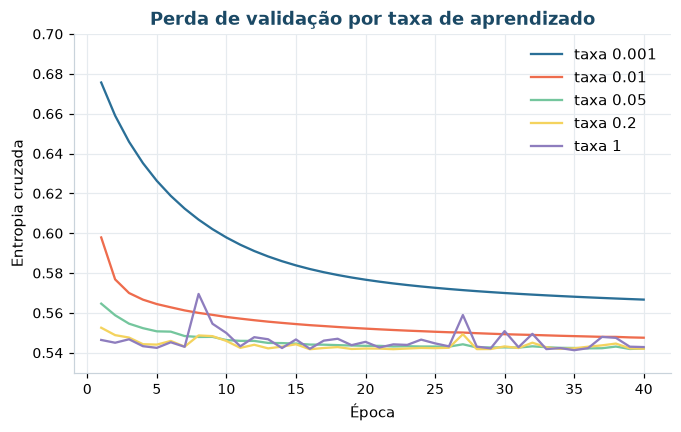

epoca,perda_val_final
taxa 0.2,0.542070
taxa 0.05,0.542183
taxa 1,0.542902
taxa 0.01,0.547593
taxa 0.001,0.566717


In [9]:
curvas = {}
for taxa in [0.001, 0.01, 0.05, 0.2, 1.0]:
    rede = MLPNumpy(n_entradas=particao.n_entradas, ocultas=(32, 16), taxa=taxa)
    rede.fit(particao.X_treino, particao.y_treino, particao.X_val, particao.y_val,
             epocas=40, paciencia=40)
    curvas[f"taxa {taxa:g}"] = rede.historico["perda_val"]

curvas = pd.DataFrame(curvas).rename_axis("epoca")
fig, eixo = plt.subplots(figsize=(7, 4))
for (nome, serie), cor in zip(curvas.items(), config.PALETA):
    eixo.plot(serie.index + 1, serie, label=nome, color=cor)
eixo.set(title="Perda de validação por taxa de aprendizado", xlabel="Época",
         ylabel="Entropia cruzada", ylim=(0.53, 0.70))
eixo.legend()
salvar_figura(fig, SECAO, "taxa-de-aprendizado", curvas)
plt.show()
curvas.tail(1).T.rename(columns=lambda _: "perda_val_final").sort_values("perda_val_final")

## Conclusões

* O neurônio linear recupera sozinho a regra da soma (pesos ≈ 1, viés ≈ 0) — é o
  gradiente descendente em sua forma mais simples.
* Com apenas pressão sistólica e idade, um único neurônio sigmoide já chega a AUC ≈ 0,78;
  o peso da pressão é cerca de 2,5 vezes o da idade.
* A rede multicamada, com todas as 16 entradas, sobe para AUC ≈ 0,80. O ganho é real, mas
  pequeno: a maior parte do sinal já está na pressão e na idade.
* A verificação numérica confirma que o backpropagation escrito à mão está correto
  (diferença relativa < 10⁻⁸).
* A taxa de aprendizado muda sobretudo a **velocidade**: com 0,001 a rede ainda não
  convergiu em 40 épocas; de 0,05 a 1,0 todas chegam ao mesmo patamar. Aqui a taxa 1,0 não
  diverge — o problema é pequeno e bem-comportado —, mas a curva já oscila de uma época
  para outra. Os próximos notebooks deixam o Keras e o PyTorch cuidarem do gradiente e usam
  otimizadores adaptativos (Adam), que dependem menos dessa escolha.